## GPU Computing - Introduction

### ****Milestone 1:** Mandelbrot Float32 Kernel (35 min)**

****Follow** `mandelbrot_tutorial.md` (attached on Moodle). Type the code yourself — that is the goal. The tutorial walks through every step. If you get stuck, peek at `mandelbrot_opencl.py` (don’t open until your own version runs).**

#### ****Step 0** — Prerequisites**

- **PyOpenCL installed and working (you verified this at the end of L09):**

In [1]:
!python -c "import pyopencl as cl; [print(p.name, [d.name for d in p.get_devices()]) for p in cl.get_platforms()]"

AMD Accelerated Parallel Processing ['gfx1035']
Intel(R) OpenCL ['AMD Ryzen 7 PRO 6850U with Radeon Graphics     ']


**should list your GPU — not just Portable Computing Language ['cpu']**

It does list my GPU **✓**

- **Your Numba Mandelbrot from MP1 in front of you. You will port its inner loop to OpenCL C.**

Noted!

**Create a new file `mandelbrot_gpu.py` in your MP3 repo and follow along.**

In [2]:
!touch mandelbrot_gpu.py

#### **Step 1 — The host/device mental model**

**A PyOpenCL program has two halves:**

| Half   | Lives in    | Written in | Role                                              |
| ------ | ----------- | ---------- | ------------------------------------------------- |
| Host   | Your Python | Python     | Allocate buffers, launch kernels, collect results |
| Device | The GPU     | OpenCL C   | The kernel — the parallel loop body               |

**Three objects connect them:**

- **Context (`cl.Context`) — "who am I talking to?" — one or more devices.**

- **Command queue (`cl.CommandQueue`) — an ordered pipe for work sent to a device.**

- **Buffer (`cl.Buffer`) — a region of device memory. Inputs and outputs live here.**

**The pattern is always: *create context + queue → allocate buffers → compile kernel → enqueue kernel → copy results back*.**

I shall note all of this! In step 2, we do this "plumbing".

#### ****Step 2 — Skeleton:** the shortest possible program that launches a kernel**

**Type this in. It does nothing useful yet, but it verifies the plumbing.**

In [3]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void hello(__global int *out) {
    int i = get_global_id(0);
    out[i] = i * i;
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N = 8
out = np.zeros(N, dtype=np.int32)
out_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, out.nbytes)

prog.hello(queue, (N,), None, out_dev)
cl.enqueue_copy(queue, out, out_dev)
queue.finish()

print(out)     # → [ 0  1  4  9 16 25 36 49]


**Run it. If this prints the squares, your whole toolchain works. If it fails, fix that now — every later step builds on it.**

In [4]:
%run mandelbrot_gpu.py

/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(


[ 0  1  4  9 16 25 36 49]


It works! (ignore warnings)

#### ****Step 3** — Kernel signature for Mandelbrot**

**Decide what the kernel needs to know. For each pixel you need:**

- **Pixel coordinates (row, col) — the kernel gets these from `get_global_id`**
- **The view window (`x_min, x_max, y_min, y_max`)**
- **Image dimension `N`**
- **`max_iter`**
- **Somewhere to write the result**

**So the signature is:**

```c
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    // body to fill in
}
```

**Add this to your Python file as the new `KERNEL_SRC`. Leave the body empty for now. Note: one work-item = one pixel. We'll launch with an NDRange of `(N, N)`, so `get_global_id(0)` gives the column and `get_global_id(1)` the row.**

In [5]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    // body to fill in
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N = 8
out = np.zeros(N, dtype=np.int32)
out_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, out.nbytes)

prog.hello(queue, (N,), None, out_dev)
cl.enqueue_copy(queue, out, out_dev)
queue.finish()

print(out)     # → [ 0  1  4  9 16 25 36 49]


I have added it. I have noted the text.

#### ****Step 4** — Map pixel → complex number**

**At the top of the body:**

```c
int col = get_global_id(0);
int row = get_global_id(1);
if (col >= N || row >= N) return;   // guard against over-launch

float c_real = x_min + col * (x_max - x_min) / (float)N;
float c_imag = y_min + row * (y_max - y_min) / (float)N;
```

**Two things to notice:**

- ****Explicit cast** `(float)N`. Integer division is a classic C bug. If you forget the cast, you get 0.0 for most pixels. (See Appendix A.)**
- ****No NumPy.** The kernel is scalar code. One work-item = one pixel = one Python loop iteration you did in MP1.**


I have noticed this!

#### ****Step 5** — Translate the escape-time loop**

**Your Numba inner loop probably looks like this:**

```python
zr, zi = 0.0, 0.0
count = 0
while count < max_iter and zr*zr + zi*zi <= 4.0:
    zr, zi = zr*zr - zi*zi + c_real, 2.0 * zr * zi + c_imag
    count += 1
```

**The OpenCL C version is line-for-line analogous, except Python's simultaneous assignment does not exist — you need a temp:**

```c
float zr = 0.0f, zi = 0.0f;
int count = 0;
while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
    float tmp = zr*zr - zi*zi + c_real;
    zi = 2.0f * zr * zi + c_imag;
    zr = tmp;
    count++;
}
result[row * N + col] = count;
```

The `f` suffix (`0.0f, 4.0f, 2.0f`) keeps literals as `float`. Without it, `4.0` is a `double`, which silently promotes the whole expression and slows the kernel on GPUs where double is expensive.

Your kernel is now complete. Copy its source into the `KERNEL_SRC` triple-quoted string.

Yes. We do indeed need a tmp variable. I shall copy it.

In [6]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;   // guard against over-launch

    float c_real = x_min + col * (x_max - x_min) / (float)N;
    float c_imag = y_min + row * (y_max - y_min) / (float)N;

    float zr = 0.0f, zi = 0.0f;
    int count = 0;
    while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
        float tmp = zr*zr - zi*zi + c_real;
        zi = 2.0f * zr * zi + c_imag;
        zr = tmp;
        count++;
    }
    result[row * N + col] = count;
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N = 8
out = np.zeros(N, dtype=np.int32)
out_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, out.nbytes)

prog.hello

#### ****Step 6** — Host code: buffers, launch, copy back**

**Below the `ctx/queue/prog` setup, add:**

```c
N, MAX_ITER = 1024, 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

image = np.zeros((N, N), dtype=np.int32)
image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

prog.mandelbrot(
    queue, (N, N), None,      # global size (N, N); let OpenCL pick local
    image_dev,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(N), np.int32(MAX_ITER),
)

cl.enqueue_copy(queue, image, image_dev)
queue.finish()
```

**Two details that matter:**

- ****Every scalar must be wrapped as `np.float32(...)` or `np.int32(...)`.** PyOpenCL won't convert Python scalars for you — a plain `1024` vs `np.int32(1024)` mismatches the kernel signature and fails silently with garbled output.**
- **`queue.finish()` is the barrier. Without it, the copy may not have completed when Python reads `image`.**

I have added it. I have noted the text above!

In [7]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;   // guard against over-launch

    float c_real = x_min + col * (x_max - x_min) / (float)N;
    float c_imag = y_min + row * (y_max - y_min) / (float)N;

    float zr = 0.0f, zi = 0.0f;
    int count = 0;
    while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
        float tmp = zr*zr - zi*zi + c_real;
        zi = 2.0f * zr * zi + c_imag;
        zr = tmp;
        count++;
    }
    result[row * N + col] = count;
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N, MAX_ITER = 1024, 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

image = np.zeros((N, N), dtype=np.in

#### ****Step 7** — Time it and save the image**

```python
import time, matplotlib.pyplot as plt

# --- Warm up (first launch triggers a kernel compile) ---
prog.mandelbrot(queue, (64, 64), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(64), np.int32(MAX_ITER))
queue.finish()

# --- Time the real run ---
t0 = time.perf_counter()
prog.mandelbrot(queue, (N, N), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(N), np.int32(MAX_ITER))
queue.finish()
elapsed = time.perf_counter() - t0

cl.enqueue_copy(queue, image, image_dev)
queue.finish()

print(f"GPU {N}x{N}: {elapsed*1e3:.1f} ms")
plt.imshow(image, cmap='hot', origin='lower'); plt.axis('off')
plt.savefig("mandelbrot_gpu.png", dpi=150, bbox_inches='tight')
```

****Done?** Record the runtime in your performance notebook and commit. That's MP3 M1.**

/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(
/tmp/ipykernel_3306/826446621.py:27: RepeatedKernelRetrieval: Kernel 'mandelbrot' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable exp

GPU 1024x1024: 2.7 ms


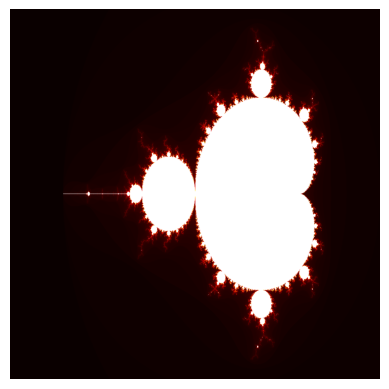

In [8]:
import time
import matplotlib.pyplot as plt
import pyopencl as cl
import numpy as np
from mandelbrot_gpu import KERNEL_SRC

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N, MAX_ITER = 1024, 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

image = np.zeros((N, N), dtype=np.int32)
image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

# --- Warm up (first launch triggers a kernel compile) ---
prog.mandelbrot(queue, (64, 64), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(64), np.int32(MAX_ITER))
queue.finish()

# --- Time the real run ---
t0 = time.perf_counter()
prog.mandelbrot(queue, (N, N), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(N), np.int32(MAX_ITER))
queue.finish()
elapsed = time.perf_counter() - t0

cl.enqueue_copy(queue, image, image_dev)
queue.finish()

print(f"GPU {N}x{N}: {elapsed*1e3:.1f} ms")
plt.imshow(image, cmap='hot', origin='lower'); plt.axis('off')
plt.savefig("mandelbrot_gpu.png", dpi=150, bbox_inches='tight')

I have now completed the `mandelbrot_tutorial.md`.

```python
# From slide 9

# Kernel signature -- fill in the body following the tutorial
KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    // ... your escape-time loop here ...
}"""

# Host launch -- note np.float32/np.int32 wrapping for every scalar
prog.mandelbrot(
    queue, (N, N), None, image_dev,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(N), np.int32(MAX_ITER),
)
queue.finish()
```

- **The kernel is a direct translation of your Numba escape-time loop into OpenCL C**

Noted! Yes it is a direct translation.

- **Each work-item computes its own *c* from its pixel coordinates — no input array needed**

Indeed yes. This was fixed in OpenCL using the `tmp` variable.

- **Launch with 2D global size `(N, N)`; wrap every scalar as `np.float32(...)/np.int32(...)`**

Done. Please see the code above from step 7.

- **Visualise with `plt.imshow` and save the image**

Done. Please see the outputted image above from step 7.

****After it produces a correct image, time it:****

- **Add a warm-up call first (first launch triggers kernel JIT compile)**

Done in step 7 above.

- **Time with `time.perf_counter()`; call `queue.finish()` before stopping the clock**

Noted! Done! Please see the code above from step 7.

****Done?** Record GPU f32 runtime in performance notebook (MP3) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit aa3a638a6259121b11a00b227528f3c6f9868ddf (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Wed Apr 22 11:06:13 2026 +0000

    l10: milestone 1 done
```

### ****Milestone 2:** Float32 vs Float64 (20 min)**

****Task:** Add a float64 version and compare speed and image quality.**

In [9]:
import pyopencl as cl
ctx   = cl.create_some_context(interactive=False)
# From slide 11

# 1. Check fp64 support
dev = ctx.devices[0]
if 'cl_khr_fp64' not in dev.extensions:
    print("No native fp64 -- Apple Silicon: emulated, expect large slowdown")

# 2. Add this pragma at the top of your f64 kernel string
#pragma OPENCL EXTENSION cl_khr_fp64 : enable

# 3. Three changes inside the kernel:
#    float  -> double
#    0.0f, 4.0f -> 0.0, 4.0     (drop the f suffix)
#     (float)N  -> (double)N

# 4. Wrap scalars as np.float64(...) in the host launch call

1. **Check that your device supports fp64 (see code example)**

No output from the code above. My device does support float64.

2. **Copy your M1 kernel; rename to `mandelbrot_f64`; change: `float` → `double`, literal suffixes `0.0f/4.0f → 0.0/4.0`; add the pragma line at the top**

In [10]:
KERNEL_SRC_F64 = """
#pragma OPENCL EXTENSION cl_khr_fp64 : enable

__kernel void mandelbrot_f64(
    __global int *result,
    const double x_min, const double x_max,
    const double y_min, const double y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;   // guard against over-launch

    double c_real = x_min + col * (x_max - x_min) / (double)N;
    double c_imag = y_min + row * (y_max - y_min) / (double)N;

    double zr = 0.0, zi = 0.0;
    int count = 0;
    while (count < max_iter && zr*zr + zi*zi <= 4.0) {
        double tmp = zr*zr - zi*zi + c_real;
        zi = 2.0 * zr * zi + c_imag;
        zr = tmp;
        count++;
    }
    result[row * N + col] = count;
}
"""

3. **Time both at $N=1024$ and $N=2048$ — what is the f32/f64 speed ratio?**

In [11]:
import numpy as np
from mandelbrot_gpu import KERNEL_SRC as KERNEL_SRC_F32

queue = cl.CommandQueue(ctx)
prog_f32 = cl.Program(ctx, KERNEL_SRC_F32).build()
prog_f64 = cl.Program(ctx, KERNEL_SRC_F64).build()

N, MAX_ITER = 1024, 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

image_1024_f32 = np.zeros((1024, 1024), dtype=np.int32)
image_dev_1024_f32 = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image_1024_f32.nbytes)
image_2048_f32 = np.zeros((2048, 2048), dtype=np.int32)
image_dev_2048_f32 = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image_2048_f32.nbytes)
image_1024_f64 = np.zeros((1024, 1024), dtype=np.int32)
image_dev_1024_f64 = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image_1024_f64.nbytes)
image_2048_f64 = np.zeros((2048, 2048), dtype=np.int32)
image_dev_2048_f64 = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image_2048_f64.nbytes)

# --- Warm up (first launch triggers a kernel compile) ---
dummy_buff_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image_1024_f32.nbytes)
prog_f32.mandelbrot(
    queue, (64, 64), None, dummy_buff_dev,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(64), np.int32(MAX_ITER)
)
queue.finish()

prog_f64.mandelbrot_f64(
    queue, (64, 64), None, dummy_buff_dev,
    np.float64(X_MIN), np.float64(X_MAX),
    np.float64(Y_MIN), np.float64(Y_MAX),
    np.int32(64), np.int32(MAX_ITER)
)
queue.finish()

/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(


In [12]:
import time

# --- Time the real run ---
# 1024 f32
t0 = time.perf_counter()
prog_f32.mandelbrot(
    queue, (1024, 1024), None, image_dev_1024_f32,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(1024), np.int32(MAX_ITER)
)
queue.finish()
elapsed_1024_f32 = time.perf_counter() - t0
cl.enqueue_copy(queue, image_1024_f32, image_dev_1024_f32)
queue.finish()
print(f"{elapsed_1024_f32=}")

# # 1024 f64
t0 = time.perf_counter()
prog_f64.mandelbrot_f64(
    queue, (1024, 1024), None, image_dev_1024_f64,
    np.float64(X_MIN), np.float64(X_MAX),
    np.float64(Y_MIN), np.float64(Y_MAX),
    np.int32(1024), np.int32(MAX_ITER)
)
queue.finish()
elapsed_1024_f64 = time.perf_counter() - t0
cl.enqueue_copy(queue, image_1024_f64, image_dev_1024_f64)
queue.finish()
print(f"{elapsed_1024_f64=}")

# # 2048 f32
t0 = time.perf_counter()
prog_f32.mandelbrot(
    queue, (2048, 2048), None, image_dev_2048_f32,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(2048), np.int32(MAX_ITER)
)
queue.finish()
elapsed_2048_f32 = time.perf_counter() - t0
cl.enqueue_copy(queue, image_2048_f32, image_dev_2048_f32)
queue.finish()
print(f"{elapsed_2048_f32=}")

# 2048 f64
t0 = time.perf_counter()
prog_f64.mandelbrot_f64(
    queue, (2048, 2048), None, image_dev_2048_f64,
    np.float64(X_MIN), np.float64(X_MAX),
    np.float64(Y_MIN), np.float64(Y_MAX),
    np.int32(2048), np.int32(MAX_ITER)
)
queue.finish()
elapsed_2048_f64 = time.perf_counter() - t0
cl.enqueue_copy(queue, image_2048_f64, image_dev_2048_f64)
queue.finish()
print(f"{elapsed_2048_f64=}")

elapsed_1024_f32=0.0015235589999065269
elapsed_1024_f64=0.007998920999852999
elapsed_2048_f32=0.002838465999957407
elapsed_2048_f64=0.01747659700049553


/tmp/ipykernel_22939/492714710.py:6: RepeatedKernelRetrieval: Kernel 'mandelbrot' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  prog_f32.mandelbrot(
/tmp/ipykernel_22939/492714710.py:20: RepeatedKernelRetrieval: Kernel 'mandelbrot_f64' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  prog_f64.mandelbrot_f64(


In [13]:
speedup_ration_1024 = elapsed_1024_f32 / elapsed_1024_f64
speedup_ration_2048 = elapsed_2048_f32 / elapsed_2048_f64

print(f"Speedup ration (1024): {speedup_ration_1024:.2f}x")
print(f"Speedup ration (2048): {speedup_ration_2048:.2f}x")

Speedup ration (1024): 0.19x
Speedup ration (2048): 0.16x


- **Is the measured speed ratio consistent with your Roofline prediction?**

Lets see if my mandelbort beats my ridge point.

In [14]:
!clpeak --platform 0 --device 0


Platform: AMD Accelerated Parallel Processing
  Device: gfx1035
    Driver version  : 3581.0 (HSA1.1,LC) (Linux x64)
    Compute units   : 6
    Clock frequency : 2200 MHz

    Global memory bandwidth (GBPS)
      float   : 76.67
      float2  : 83.27
      float4  : 83.38
      float8  : 84.04
      float16 : 86.92

    Single-precision compute (GFLOPS)
      float   : 1616.53
      float2  : 2729.83
      float4  : 2788.07
      float8  : 2704.68
      float16 : 2636.96

    Half-precision compute (GFLOPS)
      half   : 2774.83
      half2  : 5291.98
      half4  : 5218.88
      half8  : 5192.87
      half16 : 4988.41

    Double-precision compute (GFLOPS)
      double   : 198.50
      double2  : 196.64
      double4  : 196.22
      double8  : 189.17
      double16 : 189.80

    Integer compute (GIOPS)
      int   : 513.19
      int2  : 491.79
      int4  : 439.49
      int8  : 510.53
      int16 : 509.49

    Integer compute Fast 24bit (GIOPS)
      int   : 2096.29
      int2  : 1

$$\text{Bandwidth} = 80 \space \text{GB/s}$$

**Rigde point for f32**

$$\text{Peak FLOPS}_{\text{f32}} = 2,700 \space \text{GFLOPS}$$

$$\text{Ridge Point}_{\text{f32}} = \frac{2,700 \space \text{GFLOPS}}{80 \space \text{GB/s}} = 33,75 \space {\text{FLOPs/byte}}$$

**Rigde point for f64**

$$\text{Peak FLOPS}_{\text{f64}} = 197 \space \text{GFLOPS}$$

$$\text{Ridge Point}_{\text{f64}} = \frac{197 \space \text{GFLOPS}}{80 \space \text{GB/s}} = 2,46 \space {\text{FLOPs/byte}}$$

**Mandelbrot 1024**

$$ \text{Algorithmic Intensity} = \frac{\text{Number of FLOPs}}{\text{Bytes transferred from memory}} $$

```c
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;

    float c_real = x_min + col * (x_max - x_min) / (float)N;
    float c_imag = y_min + row * (y_max - y_min) / (float)N;

    float zr = 0.0f, zi = 0.0f;
    int count = 0;
    while (count < max_iter && zr*zr + zi*zi <= 4.0f) {      // 3 FLOPs
        float tmp = zr*zr - zi*zi + c_real;                  // 4 FLOPs
        zi = 2.0f * zr * zi + c_imag;                        // 3 FLOPs
        zr = tmp;
        count++;
    }
    result[row * N + col] = count;                           // Write 4 Bytes (int32)
}
```

$$\text{FLOPs per pixel} = 10 \space \text{FLOPs}$$

Lets compute the mean FLOPs computed, since the while loop iterations differ per pixel. The image is the iterations counts.

In [15]:
print(f"{np.mean(image_1024_f32)=:.4f}")
print(f"{np.mean(image_1024_f64)=:.4f}")
print(f"{np.mean(image_2048_f32)=:.4f}")
print(f"{np.mean(image_2048_f64)=:.4f}")

np.mean(image_1024_f32)=38.9546
np.mean(image_1024_f64)=38.9564
np.mean(image_2048_f32)=38.9472
np.mean(image_2048_f64)=38.9478


The difference is so small. Lets assume:

$$\text{Number of FLOPs per pixel} = 10 \space \text{FLOPs} \times 38.95 = 389.5 \space \text{FLOPs}$$

The for the full $1024$ image it is:

$$\text{Number of FLOPs} = 389.5 \space \text{FLOPs} \times 1024^2 = 408,420,352 \space \text{FLOPs} $$

Now the bytes bandwidth

$$ \text{Bytes transferred from memory}_{1024} = 1024^2 \times 4 \space \text{Bytes} = 4,194,304 \space \text{Bytes}$$

Then the Algorithmic Intensity

$$ \text{AI}_{1024} = \frac{408,420,352 \space \text{FLOPs}}{4,194,304 \space \text{Bytes}} = 97.38 \space \text{FLOPs/Byte}$$

**Mandelbrot 2048**

The only difference is the number of bandwidth bytes

$$ \text{Bytes transferred from memory}_{2048} = 2048^2 \times 4 \space \text{Bytes} = 16,777,216 \space \text{Bytes}$$

$$ \text{AI}_{2048} = \frac{408,420,352 \space \text{FLOPs}}{16,777,216 \space \text{Bytes}} = 24.34 \space \text{FLOPs/Byte}$$

Lets plot this.

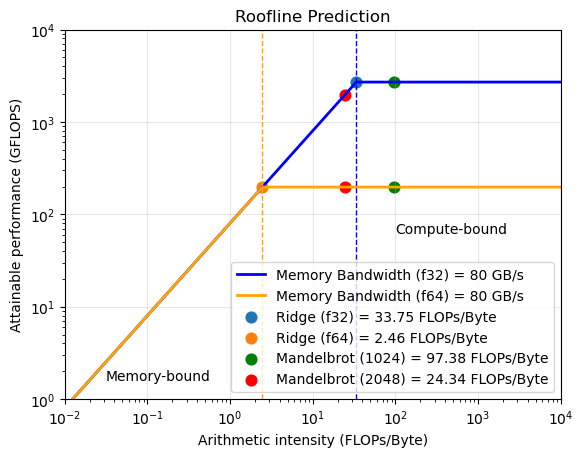

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# hardware limits
f32_peak = 2700 # GFLOPS
f64_peak = 197 # GFLOPS
memory_bandwidth = 80 # GBPS

ridge_f32 = 33.75 
ridge_f64 = 2.46
x_ridge_point_f32 = f32_peak / memory_bandwidth
x_ridge_point_f64 = f64_peak / memory_bandwidth

# Algorithmic Intensity
ai_1024 = 97.38 # FLOPs/Byte
ai_2048 = 24.34 # # FLOPs/Byte
y_ai_1024_f32 = min(memory_bandwidth * ai_1024, f32_peak)
y_ai_2048_f32 = min(memory_bandwidth * ai_2048, f32_peak)
y_ai_1024_f64 = min(memory_bandwidth * ai_1024, f64_peak)
y_ai_2048_f64 = min(memory_bandwidth * ai_2048, f64_peak)


# same axes as jimmy - plot samples
x = np.logspace(-2, 4, 200)

memory_bandwidth_limit_f32 = np.minimum(memory_bandwidth * x, f32_peak)
memory_bandwidth_limit_f64 = np.minimum(memory_bandwidth * x, f64_peak)


# float32
plt.plot(x, memory_bandwidth_limit_f32, label=f"Memory Bandwidth (f32) = {memory_bandwidth} GB/s", linewidth="2", color="blue")
plt.plot(x, memory_bandwidth_limit_f64, label=f"Memory Bandwidth (f64) = {memory_bandwidth} GB/s", linewidth="2", color="orange")
plt.scatter(x_ridge_point_f32, f32_peak, label=f"Ridge (f32) = {ridge_f32} FLOPs/Byte", s=60)
plt.scatter(x_ridge_point_f64, f64_peak, label=f"Ridge (f64) = {ridge_f64} FLOPs/Byte", s=60)
plt.scatter(ai_1024, y_ai_1024_f32, label=f"Mandelbrot (1024) = {ai_1024} FLOPs/Byte", color="green", s=60)
plt.scatter(ai_2048, y_ai_2048_f32, label=f"Mandelbrot (2048) = {ai_2048} FLOPs/Byte", color="red", s=60)
plt.scatter(ai_1024, y_ai_1024_f64, color="green", s=60)
plt.scatter(ai_2048, y_ai_2048_f64, color="red", s=60)
plt.axvline(x_ridge_point_f32, linestyle="dashed", linewidth="1", color="blue")
plt.axvline(x_ridge_point_f64, linestyle="dashed", linewidth="1", color="orange")
plt.text(10**-1.5, 10**0.2, "Memory-bound")
plt.text(10**2, 10**1.8, "Compute-bound")
plt.xlabel("Arithmetic intensity (FLOPs/Byte)")
plt.ylabel("Attainable performance (GFLOPS)")
plt.xscale("log")
plt.yscale("log")
plt.xlim(10**-2, 10**4)
plt.ylim(10**0, 10**4)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Roofline Prediction")
plt.show()


*float32:* From the plot above (the blue line), we can see that mandelbrot for the smaller image is compute bound but the smaller image is memory bounded. Both at very close at the ridge point. It seems that my cl device (GPU) was made for workloads like mandelbrot float32.

*float64:* From the plot above (the orange line) shows that both mandelbrot images are compute bounded, which is to be expected due to float64 requiring more compute per byte than float32 version.

- **Apple Silicon (M-series): fp64 is emulated in software — expect a very large slowdown**

I do not have any M-series computer.

****Done?** Record f32 and f64 runtimes in performance notebook (MP3) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit 99f8ffec365b88a4fda3c785dbb22773e0b36e01 (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Fri Apr 24 08:10:48 2026 +0000

    l10: milestone 2 done
```

### ****Milestone 3:** Benchmark GPU**

****Task:** Time your GPU kernels at the same grid sizes you used in MP1 and MP2. Reuse the CPU runtimes already in your performance notebook — no need to re-run them.**

1. **Time `mandelbrot_gpu_f32` and `mandelbrot_gpu_f64` at your benchmark *N* values**

In [17]:
import pyopencl as cl
import numpy as np

# From slide 13, adapted by me

import statistics, time, matplotlib.pyplot as plt
def timed(fn, *args, runs=3):
    return statistics.median([fn(*args) for _ in range(runs)])

In [18]:
from mandelbrot_gpu import KERNEL_SRC as KERNEL_SRC_F32

def run_mandelbrot_f32(N):
    ctx   = cl.create_some_context(interactive=False)
    queue = cl.CommandQueue(ctx)
    prog  = cl.Program(ctx, KERNEL_SRC_F32).build()

    # Same parameters used in mp2
    MAX_ITER = 100
    X_MIN, X_MAX = -2.0, 1.0
    Y_MIN, Y_MAX = -1.5, 1.5

    image = np.zeros((N, N), dtype=np.int32)
    image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

    # --- Warm up (first launch triggers a kernel compile) ---
    prog.mandelbrot(queue, (64, 64), None, image_dev,
                    np.float32(X_MIN), np.float32(X_MAX),
                    np.float32(Y_MIN), np.float32(Y_MAX),
                    np.int32(64), np.int32(MAX_ITER))
    queue.finish()

    # --- Time the real run ---
    t0 = time.perf_counter()
    prog.mandelbrot(queue, (N, N), None, image_dev,
                    np.float32(X_MIN), np.float32(X_MAX),
                    np.float32(Y_MIN), np.float32(Y_MAX),
                    np.int32(N), np.int32(MAX_ITER))
    queue.finish()
    return time.perf_counter() - t0

def run_mandelbrot_f64(N):
    ctx   = cl.create_some_context(interactive=False)
    queue = cl.CommandQueue(ctx)
    prog  = cl.Program(ctx, KERNEL_SRC_F64).build()

    # Same parameters used in mp2
    MAX_ITER = 100
    X_MIN, X_MAX = -2.0, 1.0
    Y_MIN, Y_MAX = -1.5, 1.5

    image = np.zeros((N, N), dtype=np.int32)
    image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

    # --- Warm up (first launch triggers a kernel compile) ---
    prog.mandelbrot_f64(queue, (64, 64), None, image_dev,
                    np.float64(X_MIN), np.float64(X_MAX),
                    np.float64(Y_MIN), np.float64(Y_MAX),
                    np.int32(64), np.int32(MAX_ITER))
    queue.finish()

    # --- Time the real run ---
    t0 = time.perf_counter()
    prog.mandelbrot_f64(queue, (N, N), None, image_dev,
                    np.float64(X_MIN), np.float64(X_MAX),
                    np.float64(Y_MIN), np.float64(Y_MAX),
                    np.int32(N), np.int32(MAX_ITER))
    queue.finish()
    return time.perf_counter() - t0

2. **Combine GPU runtimes with your recorded MP1/MP2 numbers**

In [19]:
# From slide 13, filled in with my used values
N = 4096                        # match your MP1/MP2 benchmark N
results = {
    "GPU f32": timed(lambda: run_mandelbrot_f32(N)),
    "GPU f64": timed(lambda: run_mandelbrot_f64(N)),
    # Paste your MP1/MP2 runtimes here:
    "Naive": 67.556, 
    "NumPy": 11.321, 
    "Numba": 0.751,
    "Multiprocessing": 0.359,
    "Dask Local": 0.738,
    "Dask Cluster": 0.540
}

print(f"GPU (f32): {results['GPU f32']:.3f}s")
print(f"GPU (f64): {results['GPU f64']:.3f}s")

/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(
/tmp/ipykernel_614/390168630.py:25: RepeatedKernelRetrieval: Kernel 'mandelbrot' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expe

GPU (f32): 0.006s
GPU (f64): 0.033s


3. **Plot as a bar chart with a log-scale y -axis — this is the MP3 performance comparison figure**

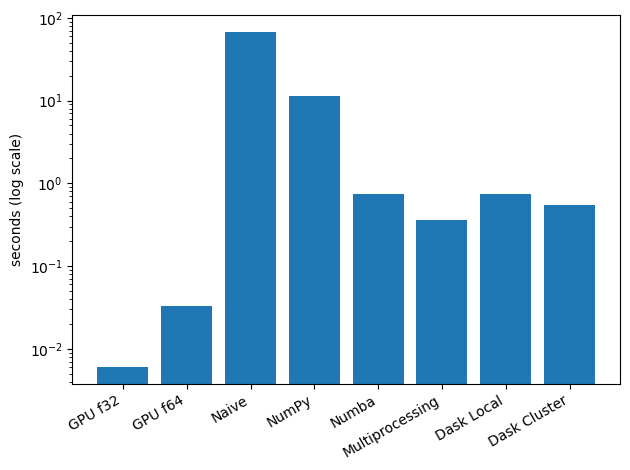

In [20]:
names, times = zip(*results.items())
plt.bar(names, times, log=True)
plt.ylabel("seconds (log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("benchmark_mp3.png", dpi=150)

- **Include: naive Python, NumPy, Numba f32/f64, multiprocessing, Dask local, Dask cluster, GPU f32, GPU f64**

I am only missing the Numba for f32 and f64 at 4096.

In [21]:
from numba import njit


# From lecture 3

@njit
def mandelbrot_point_numba(c, max_iter=100):
    z = 0j
    for n in range(max_iter):
        if z.real*z.real+z.imag*z.imag > 4.0:
            return n
        z = z*z + c
    return max_iter

@njit
def mandelbrot_numba_typed(xmin, xmax, ymin, ymax,
                            width, height, max_iter=100, dtype=np.float64):
    x = np.linspace(xmin, xmax, width).astype(dtype)
    y = np.linspace(ymin, ymax, height).astype(dtype)
    result = np.zeros((height, width), dtype=np.int32)
    for i in range(height):
        for j in range(width):
            c = x[j] + 1j * y[i]
            result[i, j] = mandelbrot_point_numba(c, max_iter)
    return result

In [22]:
from timeit import timeit

# warmup
mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 4096, 4096, dtype=np.float32)
mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 4096, 4096, dtype=np.float64)

results_plus_numba = {
    **results,
    "Numba f32": timeit(lambda: mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 4096, 4096, dtype=np.float32), number=3)/3,
    "Numba f64": timeit(lambda: mandelbrot_numba_typed(-2, 1, -1.5, 1.5, 4096, 4096, dtype=np.float64), number=3)/3,
}

del results_plus_numba["Numba"]

- **Where does GPU sit relative to Numba? To naive Python? (Recall the L01 starting point.)**

Numba f32 0.731 s
Numba f64 0.707 s


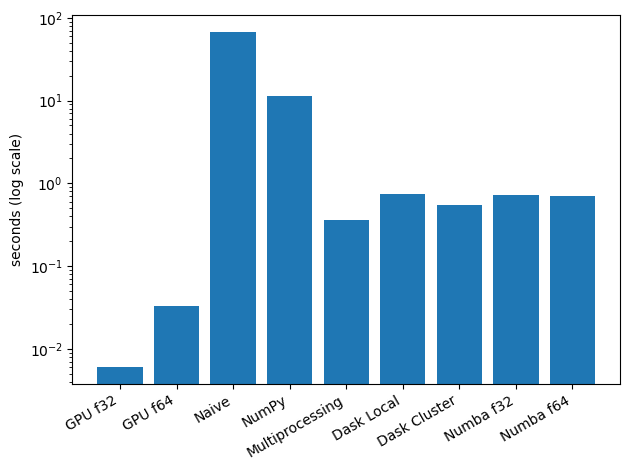

In [23]:
print(f"Numba f32 {results_plus_numba['Numba f32']:.3f} s")
print(f"Numba f64 {results_plus_numba['Numba f64']:.3f} s")

names, times = zip(*results_plus_numba.items())
plt.bar(names, times, log=True)
plt.ylabel("seconds (log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("benchmark_mp3.png", dpi=150)

In [24]:
gpu_numba_relative = results_plus_numba["Numba f32"] / results_plus_numba["GPU f32"]
gpu_naive_relative = results_plus_numba["Naive"] / results_plus_numba["GPU f32"]

print(f"GPU is {gpu_numba_relative:.2f}x times faster compared to Numba")
print(f"GPU is {gpu_naive_relative:.2f}x times faster compared to Naive Python")

GPU is 121.13x times faster compared to Numba
GPU is 11189.24x times faster compared to Naive Python


****Done?** Combined benchmark chart in performance notebook (MP3) → commit**

The benchmark chart is combined above.

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit a5f110eefef83e3c00a712f61864cc6b6c4b940e (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Fri Apr 24 11:30:21 2026 +0000

    l10: milestone 3 done
```